In [2]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 48.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import  classification_report, accuracy_score, confusion_matrix

In [4]:
import rasterio
import pandas as pd
import numpy as np
from skimage.transform import resize  # For resizing rasters to a common shape

# Function to read and resize GeoTIFFs
def read_geotiff(file_path, target_shape=None):
    with rasterio.open(file_path) as dataset:
        data = dataset.read(1)  # Read the first band
        if target_shape is not None:
            # Resize to match target_shape (if provided)
            data = resize(data, target_shape, preserve_range=True, anti_aliasing=False)
        return data.flatten()  # Flatten to 1D array for DataFrame

# Dictionary of file paths (replace with your actual paths if different)
files = {
    'Aspect': '/content/drive/MyDrive/parmarth/final tiff parameters/Aspect_Final.tif',
    'Distance_from_stream': '/content/drive/MyDrive/parmarth/final tiff parameters/Distance_To_Stream.tif',
    'LULC': '/content/drive/MyDrive/parmarth/final tiff parameters/LULC_Final.tif',
    'Rainfall': '/content/drive/MyDrive/parmarth/final tiff parameters/Max_Rainfall.tif',
    'Slope': '/content/drive/MyDrive/parmarth/final tiff parameters/Slope_Final.tif',
    'Soil': '/content/drive/MyDrive/parmarth/final tiff parameters/soil_final_2.tif',
    'SPI': '/content/drive/MyDrive/parmarth/final tiff parameters/spi.tif',
    'Drainage_density': '/content/drive/MyDrive/parmarth/final tiff parameters/Drainage_den_final.tif',
    'TWI': '/content/drive/MyDrive/parmarth/final tiff parameters/TWI_Final.tif',
    'lin_density': '/content/drive/MyDrive/parmarth/final tiff parameters/lin_density_final.tif',
    'Geomorphology': '/content/drive/MyDrive/parmarth/final tiff parameters/Geomorphology_final.tif',
    'Geology': '/content/drive/MyDrive/parmarth/final tiff parameters/Geology_final.tif',
    'LS_points': '/content/drive/MyDrive/parmarth/final tiff parameters/LS_points_final.tif'
}

# Step 1: Find the smallest common shape across all rasters
shapes = []
for file_path in files.values():
    with rasterio.open(file_path) as dataset:
        shapes.append(dataset.shape)

# Use the smallest dimensions (to avoid padding with NaNs)
min_rows = min(s[0] for s in shapes)
min_cols = min(s[1] for s in shapes)
target_shape = (min_rows, min_cols)

# Step 2: Read and resize all rasters to the target shape
data_dict = {}
for layer_name, file_path in files.items():
    data_dict[layer_name] = read_geotiff(file_path, target_shape)

# Step 3: Create DataFrame
df = pd.DataFrame(data_dict)
print(df.head())  # Verify the output

         Aspect  Distance_from_stream   LULC      Rainfall         Slope  \
0 -3.402823e+38         -3.402823e+38  255.0 -3.402823e+38 -3.402823e+38   
1 -3.402823e+38         -3.402823e+38  255.0 -3.402823e+38 -3.402823e+38   
2 -3.402823e+38         -3.402823e+38  255.0 -3.402823e+38 -3.402823e+38   
3 -3.402823e+38         -3.402823e+38  255.0 -3.402823e+38 -3.402823e+38   
4 -3.402823e+38         -3.402823e+38  255.0 -3.402823e+38 -3.402823e+38   

   Soil           SPI  Drainage_density           TWI  lin_density  \
0   0.0 -3.402823e+38               0.0 -3.402823e+38          0.0   
1   0.0 -3.402823e+38               0.0 -3.402823e+38          0.0   
2   0.0 -3.402823e+38               0.0 -3.402823e+38          0.0   
3   0.0 -3.402823e+38               0.0 -3.402823e+38          0.0   
4   0.0 -3.402823e+38               0.0 -3.402823e+38          0.0   

   Geomorphology  Geology  LS_points  
0            0.0      0.0        0.0  
1            0.0      0.0        0.0  
2    

In [5]:
df.head()

,Aspect,Distance_from_stream,LULC,Rainfall,Slope,Soil,SPI,Drainage_density,TWI,lin_density,Geomorphology,Geology,LS_points
0,-3.402823e+38,-3.402823e+38,255.0,-3.402823e+38,-3.402823e+38,0.0,-3.402823e+38,0.0,-3.402823e+38,0.0,0.0,0.0,0.0
1,-3.402823e+38,-3.402823e+38,255.0,-3.402823e+38,-3.402823e+38,0.0,-3.402823e+38,0.0,-3.402823e+38,0.0,0.0,0.0,0.0
2,-3.402823e+38,-3.402823e+38,255.0,-3.402823e+38,-3.402823e+38,0.0,-3.402823e+38,0.0,-3.402823e+38,0.0,0.0,0.0,0.0
3,-3.402823e+38,-3.402823e+38,255.0,-3.402823e+38,-3.402823e+38,0.0,-3.402823e+38,0.0,-3.402823e+38,0.0,0.0,0.0,0.0
4,-3.402823e+38,-3.402823e+38,255.0,-3.402823e+38,-3.402823e+38,0.0,-3.402823e+38,0.0,-3.402823e+38,0.0,0.0,0.0,0.0


In [7]:
# from google.colab import files

# # Export DataFrame to CSV
# df.to_csv('LS_dataframe.csv', index=False)  # Set index=False if you don't want to save row indices

# # Download the file to your local system
# files.download('LS_dataframe.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
df.shape

(2581416, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2581416 entries, 0 to 2581415
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Aspect                float32
 1   Distance_from_stream  float32
 2   LULC                  float64
 3   Rainfall              float32
 4   Slope                 float32
 5   Soil                  float64
 6   SPI                   float32
 7   Drainage_density      float64
 8   TWI                   float32
 9   lin_density           float64
 10  Geomorphology         float64
 11  Geology               float64
 12  LS_points             float64
dtypes: float32(6), float64(7)
memory usage: 196.9 MB


In [10]:
df.describe()

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy

,Aspect,Distance_from_stream,LULC,Rainfall,Slope,Soil,SPI,Drainage_density,TWI,lin_density,Geomorphology,Geology,LS_points
count,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06,2.581416e+06
mean,-inf,-inf,2.223160e+02,-inf,-inf,1.665293e-01,-inf,2.868149e-02,-inf,8.463959e-03,1.664282e-01,1.655711e-01,3.508410e-04
std,inf,inf,7.734007e+01,inf,inf,3.711398e-01,inf,1.309527e-01,inf,9.160963e-02,3.710455e-01,3.702738e-01,1.332102e-02
min,-3.402823e+38,-3.402823e+38,1.100000e+01,-3.402823e+38,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,-3.402823e+38,-3.402823e+38,2.550000e+02,-3.402823e+38,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,-3.402823e+38,-3.402823e+38,2.550000e+02,-3.402823e+38,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,-3.402823e+38,-3.402823e+38,2.550000e+02,-3.402823e+38,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,-3.402823e+38,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,3.584177e+02,2.355656e+04,2.550000e+02,4.580400e+03,6.425777e+01,1.000000e+00,1.764491e+06,1.000000e+00,1.795481e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [11]:
df.isnull().sum()

,0
Aspect,0
Distance_from_stream,0
LULC,0
Rainfall,0
Slope,0
Soil,0
SPI,0
Drainage_density,0
TWI,0
lin_density,0


In [12]:
df.columns

Index(['Aspect', 'Distance_from_stream', 'LULC', 'Rainfall', 'Slope', 'Soil',
       'SPI', 'Drainage_density', 'TWI', 'lin_density', 'Geomorphology',
       'Geology', 'LS_points'],
      dtype='object')

after this split and training will happen

In [13]:
df['LS_points'].value_counts()

,count
LS_points,
0.000000,2578325
0.114551,4
0.948448,4
0.944272,3
0.306502,3
...,...
0.269266,1
0.588537,1
0.113631,1


In [14]:
df.loc[df['LS_points'] > 0, 'LS_points'] = 1

In [15]:
df['LS_points'].value_counts()

,count
LS_points,
0.0,2578325
1.0,3091


In [16]:
from google.colab import files

# Export DataFrame to CSV
df.to_csv('LS_data1.csv', index=False)  # Set index=False if you don't want to save row indices

# Download the file to your local system
files.download('LS_data1.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
df.columns

Index(['Aspect', 'Distance_from_stream', 'LULC', 'Rainfall', 'Slope', 'Soil',
       'SPI', 'Drainage_density', 'TWI', 'lin_density', 'Geomorphology',
       'Geology', 'LS_points'],
      dtype='object')

In [21]:
!pip uninstall numpy -y
!pip install numpy --upgrade

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 61.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Features (X) and Target (y)
X = df.drop('LS_points', axis=1)  # All columns except target
y = df['LS_points']  # Target column (binary: 0 or 1)

# Split into 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Train, predict, and evaluate each model
for model_name, model in models.items():
    print("="*50)
    print(model_name)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Classification Report & Accuracy
    print(classification_report(y_test, predictions))
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")

    # AUC Score
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"AUC: {auc:.4f}")
    else:
        print("AUC: Not available (model does not support probabilities)")

    print("\n")

Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.03      0.00      0.00       898

    accuracy                           1.00    774425
   macro avg       0.51      0.50      0.50    774425
weighted avg       1.00      1.00      1.00    774425

Accuracy: 0.9988
AUC: 0.6101


Decision Tree
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.04      0.04      0.04       898

    accuracy                           1.00    774425
   macro avg       0.52      0.52      0.52    774425
weighted avg       1.00      1.00      1.00    774425

Accuracy: 0.9979
AUC: 0.2247


AdaBoost


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.00      0.00      0.00       898

    accuracy                           1.00    774425
   macro avg       0.50      0.50      0.50    774425
weighted avg       1.00      1.00      1.00    774425

Accuracy: 0.9988
AUC: 0.8479


Gradient Boosting
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.00      0.00      0.00       898

    accuracy                           1.00    774425
   macro avg       0.50      0.50      0.50    774425
weighted avg       1.00      1.00      1.00    774425

Accuracy: 0.9988
AUC: 0.8681


XGBoost
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.22      0.00      0.00       898

    accuracy                           1.00    774425
   macro avg       0.61      0.50      0

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    773527
         1.0       0.00      0.00      0.00       898

    accuracy                           1.00    774425
   macro avg       0.50      0.50      0.50    774425
weighted avg       1.00      1.00      1.00    774425

Accuracy: 0.9988
AUC: 0.5000




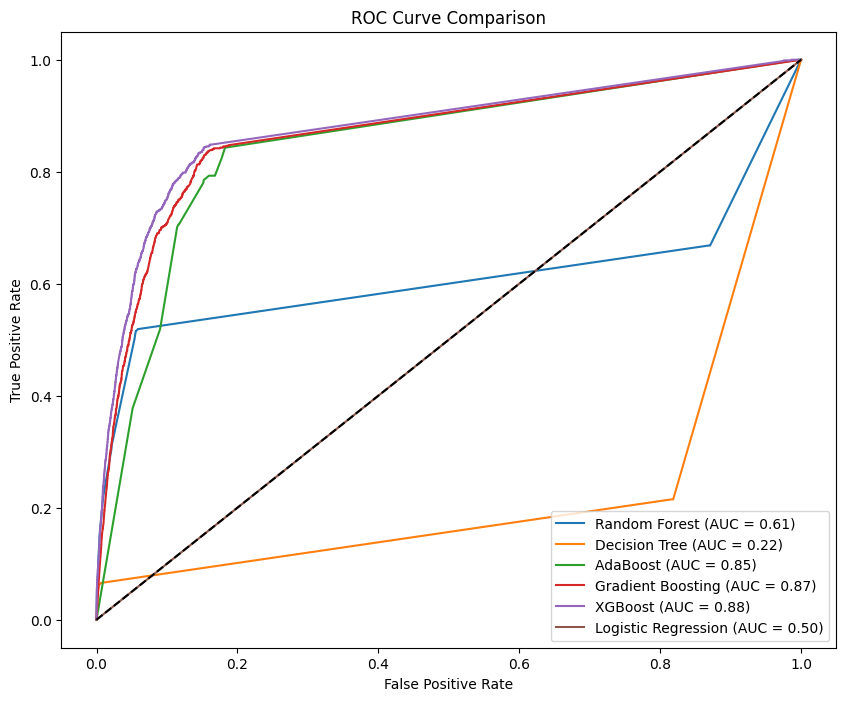

In [24]:
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

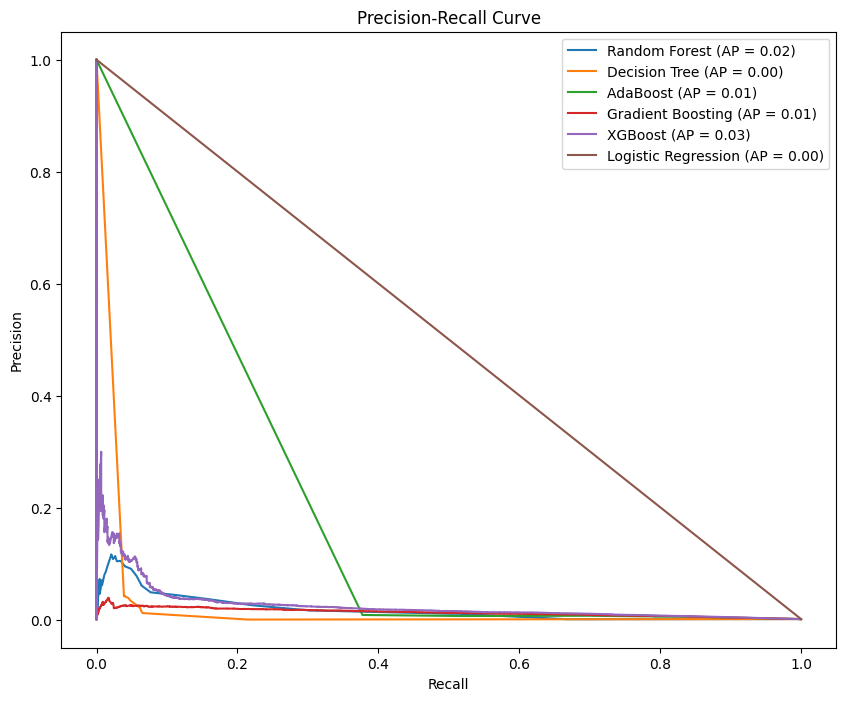

In [25]:
 #Precision-Recall Curve (Better when class imbalance exists)
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        avg_precision = average_precision_score(y_test, y_proba)
        plt.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

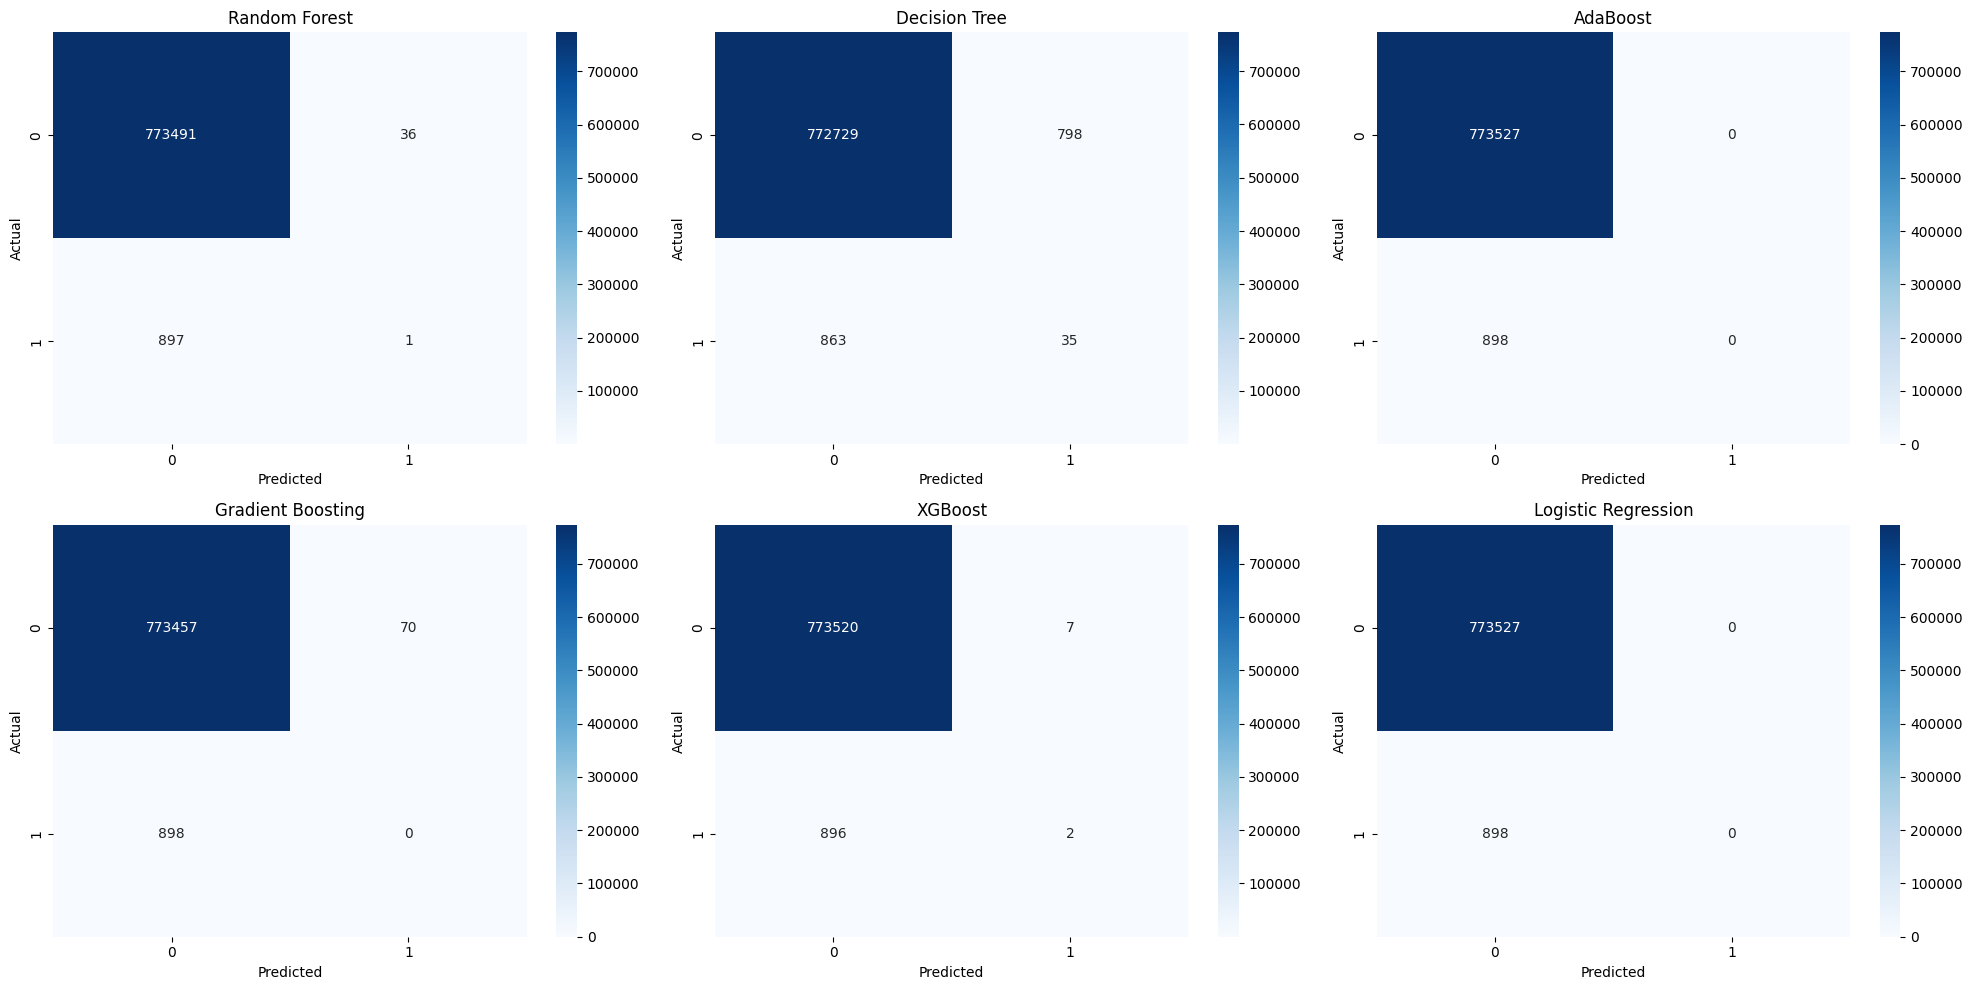

In [26]:
# Confusion Matrix Heatmaps (Side-by-Side)
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):
    predictions = model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

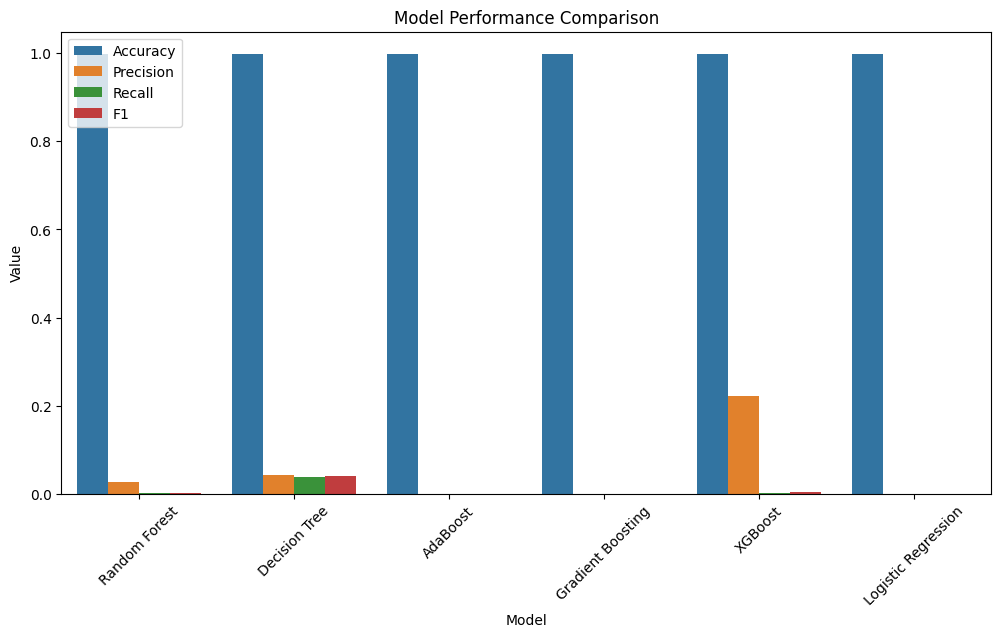

In [28]:
# Bar Plot for Metrics Comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize an empty list to store metrics
metrics_list = []

for model_name, model in models.items():
    predictions = model.predict(X_test)
    metrics_list.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions, zero_division=0)
    })

# Convert list to DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Melt for seaborn
melted_df = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=melted_df)
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


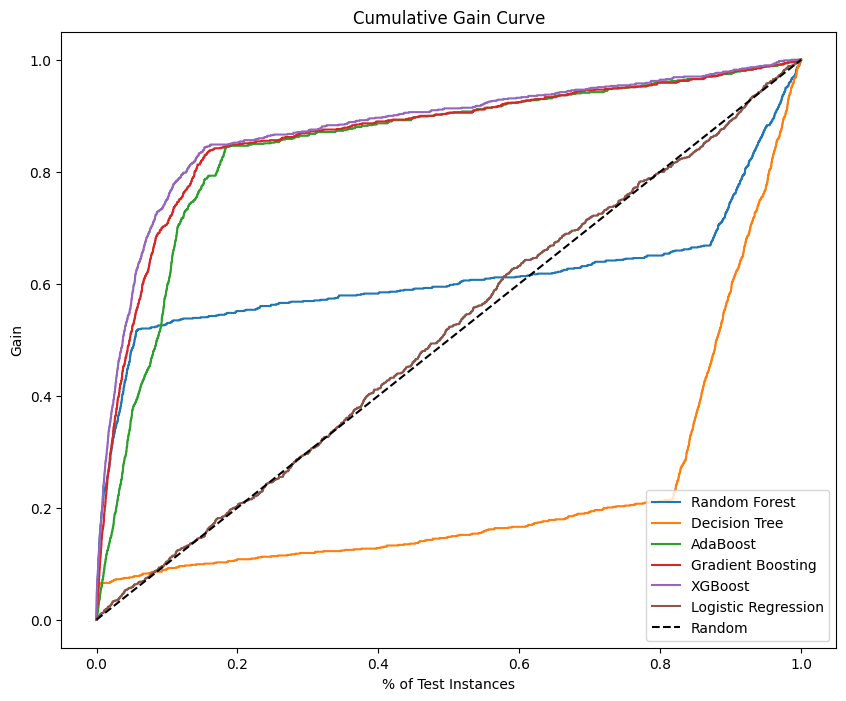

In [29]:
# Bar Plot for Metrics Comparison
from sklearn.metrics import auc

plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        sorted_idx = np.argsort(y_proba)[::-1]
        y_test_sorted = y_test.iloc[sorted_idx]
        cumulative_gain = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
        plt.plot(np.arange(1, len(y_test)+1) / len(y_test), cumulative_gain, label=model_name)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('% of Test Instances')
plt.ylabel('Gain')
plt.title('Cumulative Gain Curve')
plt.legend()
plt.show()